IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)

LOAD DATASET

In [3]:
patients = pd.read_csv("patients.csv")
doctors = pd.read_csv("doctors.csv")
appointments = pd.read_csv("appointments.csv")
billing = pd.read_csv("billing.csv")
treatments = pd.read_csv("treatments.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


BASIC DATA INSPECTION

In [4]:
print("Patients shape:", patients.shape)
print("Doctors shape:", doctors.shape)
print("Appointments shape:", appointments.shape)
print("Billing shape:", billing.shape)
print("Treatments shape:", treatments.shape)

Patients shape: (50, 11)
Doctors shape: (10, 8)
Appointments shape: (200, 7)
Billing shape: (200, 7)
Treatments shape: (200, 6)


In [5]:
patients.isnull().sum()
doctors.isnull().sum()
appointments.isnull().sum()
billing.isnull().sum()
treatments.isnull().sum()

treatment_id      0
appointment_id    0
treatment_type    0
description       0
cost              0
treatment_date    0
dtype: int64

DATA PREPROCESSING

In [9]:

patients['date_of_birth'] = pd.to_datetime(patients['date_of_birth'])
patients['registration_date'] = pd.to_datetime(patients['registration_date'])

appointments['appointment_date'] = pd.to_datetime(appointments['appointment_date'])
treatments['treatment_date'] = pd.to_datetime(treatments['treatment_date'])
billing['bill_date'] = pd.to_datetime(billing['bill_date'])

In [10]:
patients['age'] = (pd.Timestamp('today') - patients['date_of_birth']).dt.days // 365
patients[['patient_id', 'age']].head()

,patient_id,age
0,P001,70
1,P002,41
2,P003,48
3,P004,45
4,P005,65


DATA MERGING

In [13]:
# appointments + patients
df = appointments.merge(patients, on='patient_id', how='left')

# + doctors
df = df.merge(doctors, on='doctor_id', how='left')

# + treatments
df = df.merge(treatments, on='appointment_id', how='left')

# + billing
df = df.merge(billing, on=['patient_id','treatment_id'], how='left')



In [14]:
df.describe()

,appointment_date,date_of_birth,contact_number,registration_date,age,phone_number,years_experience,cost,treatment_date,bill_date,amount
count,200,200,2.000000e+02,200,200.000000,2.000000e+02,200.000000,200.000000,200,200,200.000000
mean,2023-06-17 11:38:24,1982-10-09 15:00:00,7.860191e+09,2022-05-25 15:00:00,42.935000,7.993392e+09,21.520000,2756.249250,2023-06-17 11:38:24,2023-06-17 11:38:24,2756.249250
min,2023-01-01 00:00:00,1950-01-26 00:00:00,6.141952e+09,2021-01-23 00:00:00,20.000000,6.176384e+09,5.000000,534.030000,2023-01-01 00:00:00,2023-01-01 00:00:00,534.030000
25%,2023-03-27 18:00:00,1970-02-06 00:00:00,7.081397e+09,2021-09-24 00:00:00,32.000000,6.594222e+09,19.000000,1563.412500,2023-03-27 18:00:00,2023-03-27 18:00:00,1563.412500
50%,2023-06-10 00:00:00,1987-01-14 00:00:00,7.765391e+09,2022-05-20 00:00:00,39.000000,8.322010e+09,23.000000,2828.165000,2023-06-10 00:00:00,2023-06-10 00:00:00,2828.165000
75%,2023-09-15 12:00:00,1994-02-22 00:00:00,8.618059e+09,2023-04-27 00:00:00,56.000000,9.004382e+09,26.000000,3836.627500,2023-09-15 12:00:00,2023-09-15 12:00:00,3836.627500
max,2023-12-30 00:00:00,2005-05-15 00:00:00,9.900972e+09,2023-12-12 00:00:00,76.000000,9.118539e+09,28.000000,4973.630000,2023-12-30 00:00:00,2023-12-30 00:00:00,4973.630000
std,NaN,NaN,9.421779e+08,NaN,16.078038,1.091853e+09,5.920716,1298.125308,NaN,NaN,1298.125308


In [15]:
df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name_x,last_name_x,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email_x,age,first_name_y,last_name_y,specialization,phone_number,years_experience,hospital_branch,email_y,treatment_id,treatment_type,description,cost,treatment_date,bill_id,bill_date,amount,payment_method,payment_status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com,76,Sarah,Smith,Pediatrics,7387087517,26,Central Hospital,dr.sarah.smith@hospital.com,T001,Chemotherapy,Basic screening,3941.97,2023-08-09,B001,2023-08-09,3941.97,Insurance,Pending
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com,45,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com,T002,MRI,Advanced protocol,4158.44,2023-06-09,B002,2023-06-09,4158.44,Insurance,Paid
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com,42,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com,T003,MRI,Standard procedure,3731.55,2023-06-28,B003,2023-06-28,3731.55,Insurance,Paid
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,Robert,Wilson,M,1966-08-14,7482069727,123 Elm St,2021-09-09,HealthIndia,INS833429,robert.wilson@mail.com,59,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com,T004,MRI,Basic screening,4799.86,2023-09-01,B004,2023-09-01,4799.86,Insurance,Failed
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show,Emily,Williams,M,1972-05-30,7587653815,456 Oak Ave,2021-10-16,PulseSecure,INS320984,emily.williams@mail.com,53,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com,T005,ECG,Standard procedure,582.05,2023-07-06,B005,2023-07-06,582.05,Credit Card,Pending


In [16]:
df.tail()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name_x,last_name_x,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email_x,age,first_name_y,last_name_y,specialization,phone_number,years_experience,hospital_branch,email_y,treatment_id,treatment_type,description,cost,treatment_date,bill_id,bill_date,amount,payment_method,payment_status
195,A196,P045,D006,2023-10-26,9:45:00,Checkup,Cancelled,Linda,Miller,F,1966-04-25,7579616535,321 Maple Dr,2021-01-23,MedCare Plus,INS701863,linda.miller@mail.com,59,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com,T196,Chemotherapy,Advanced protocol,2477.80,2023-10-26,B196,2023-10-26,2477.80,Cash,Pending
196,A197,P001,D005,2023-04-01,13:30:00,Emergency,No-show,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com,70,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com,T197,Physiotherapy,Standard procedure,975.49,2023-04-01,B197,2023-04-01,975.49,Cash,Pending
197,A198,P022,D006,2023-05-15,8:30:00,Therapy,No-show,John,Brown,M,1955-05-10,6221099573,321 Maple Dr,2021-05-11,MedCare Plus,INS258823,john.brown@mail.com,70,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com,T198,ECG,Basic screening,3383.72,2023-05-15,B198,2023-05-15,3383.72,Cash,Failed
198,A199,P017,D001,2023-05-01,12:45:00,Follow-up,Completed,Jane,Jones,M,1991-05-01,6158428240,456 Oak Ave,2022-09-26,WellnessCorp,INS182074,jane.jones@mail.com,34,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com,T199,Chemotherapy,Basic screening,1472.17,2023-05-01,B199,2023-05-01,1472.17,Credit Card,Paid
199,A200,P007,D005,2023-12-30,10:15:00,Consultation,Cancelled,Alex,Johnson,F,1989-06-08,6278710077,789 Pine Rd,2021-12-25,MedCare Plus,INS465890,alex.johnson@mail.com,36,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com,T200,X-Ray,Basic screening,3288.15,2023-12-30,B200,2023-12-30,3288.15,Insurance,Paid


KEY PERFORMANCE INDICATOR(KPIs)

In [17]:
print("Total Patients:", patients['patient_id'].nunique())

Total Patients: 50


In [18]:
print("Total Doctors:", doctors['doctor_id'].nunique())

Total Doctors: 10


In [19]:
total_revenue = billing['amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 551249.8500000001


In [20]:
appointments['status'].value_counts()

status
No-show      52
Scheduled    51
Cancelled    51
Completed    46
Name: count, dtype: int64

VISUALIZATION(EDA)

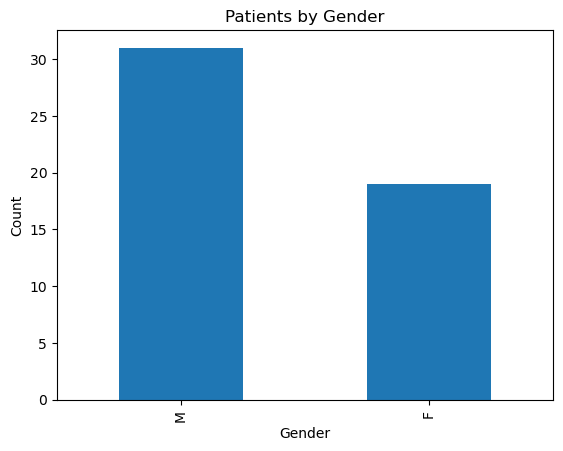

In [21]:
patients['gender'].value_counts().plot(kind='bar')
plt.title("Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

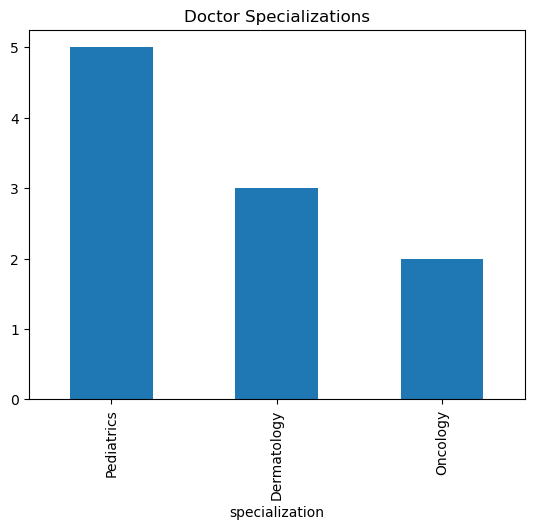

In [22]:
doctors['specialization'].value_counts().plot(kind='bar')
plt.title("Doctor Specializations")
plt.show()

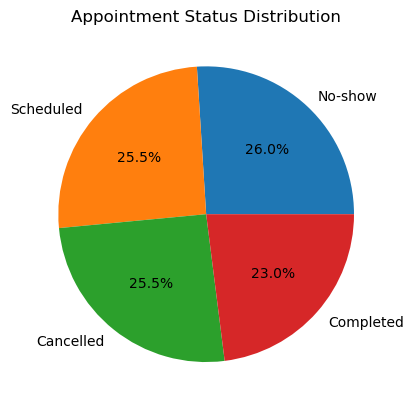

In [23]:
appointments['status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Appointment Status Distribution")
plt.ylabel("")
plt.show()

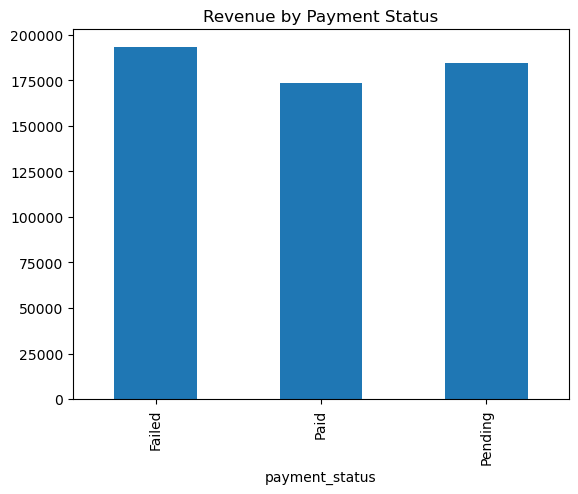

In [24]:
billing.groupby('payment_status')['amount'].sum().plot(kind='bar')
plt.title("Revenue by Payment Status")
plt.show()

SIMPLE MACHINE LEARNING

In [26]:
ml_df = appointments.copy()

ml_df['status'] = ml_df['status'].apply(
    lambda x: 1 if x == 'No-show' else 0
)



In [29]:
ml_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,0
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,1
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,0
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,0
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,1


In [30]:
ml_df.tail()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
195,A196,P045,D006,2023-10-26,9:45:00,Checkup,0
196,A197,P001,D005,2023-04-01,13:30:00,Emergency,1
197,A198,P022,D006,2023-05-15,8:30:00,Therapy,1
198,A199,P017,D001,2023-05-01,12:45:00,Follow-up,0
199,A200,P007,D005,2023-12-30,10:15:00,Consultation,0


In [31]:
ml_df = pd.get_dummies(ml_df, columns=['reason_for_visit'], drop_first=True)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = ml_df.drop(['appointment_id','patient_id','doctor_id','status',
                'appointment_date','appointment_time'], axis=1)

y = ml_df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.825


In [33]:
df.to_csv("hospital_master_data.csv", index=False)
print("Master dataset saved!")

Master dataset saved!


In [34]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))